# Geographic Analysis

## Objective

This notebook explores the geographic distribution of startups, funding, and acquisitions across countries, regions, and cities.

### Key Questions

1. Which countries have the most startups?
2. Which cities have the most startups?
3. Which countries attract the most funding?
4. Which cities attract the most funding?
5. Which locations produce the most startup acquisitions?

## Business Question

Which countries contain the largest number of startups?

### Why This Matters

Identifying countries with large startup populations helps reveal major startup ecosystems around the world.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(
    "../data/raw/investments_VC.csv",
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

In [16]:
country_counts = (
    df["country_code"]
    .value_counts()
    .head(15)
)

country_counts

country_code
USA    28793
GBR     2642
CAN     1405
CHN     1239
DEU      968
FRA      866
IND      849
ISR      682
ESP      549
RUS      368
SWE      315
AUS      314
ITA      308
NLD      307
IRL      306
Name: count, dtype: int64

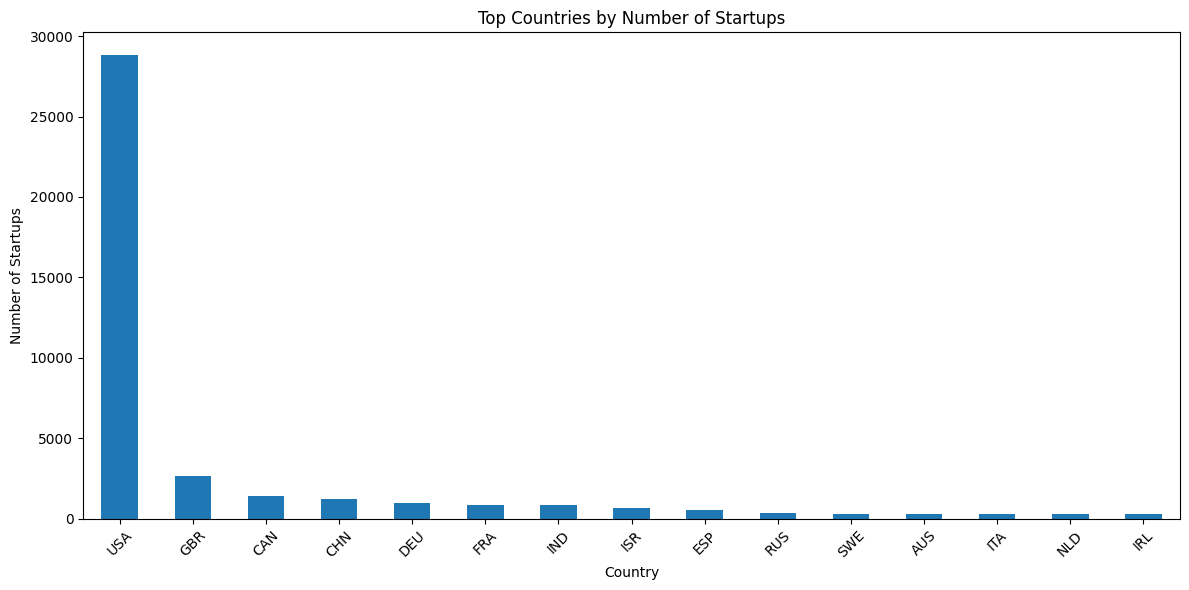

In [17]:
plt.figure(figsize=(12,6))

country_counts.plot(kind="bar")

plt.title("Top Countries by Number of Startups")
plt.xlabel("Country")
plt.ylabel("Number of Startups")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Key Insight: Countries with the Most Startups

This analysis identifies the countries with the largest startup populations.

### Findings

- The United States overwhelmingly dominates the dataset, with nearly 29,000 startups.
- The United Kingdom ranks second but has a significantly smaller startup population.
- Canada, China, Germany, France, and India form the next tier of startup ecosystems.
- Most countries outside the United States have startup counts below 3,000.

### Interpretation

The results highlight the exceptional scale of the United States startup ecosystem.

Factors contributing to this dominance may include:
- Access to venture capital
- Strong entrepreneurial culture
- Mature technology hubs
- Large domestic markets

The presence of countries such as the United Kingdom, Canada, China, and India indicates that startup activity is distributed globally, although at a much smaller scale.

### Conclusion

Startup activity is highly concentrated in the United States, which serves as the world's largest startup ecosystem by a substantial margin.

Which Cities Have the Most Startups?

In [18]:
city_counts = (
    df["city"]
    .dropna()
    .value_counts()
    .head(15)
)

city_counts

city
San Francisco    2615
New York         2334
London           1257
Palo Alto         597
Austin            583
Cambridge         554
Seattle           554
Chicago           514
Los Angeles       508
Mountain View     497
San Diego         483
Beijing           482
Boston            460
Paris             433
Toronto           378
Name: count, dtype: int64

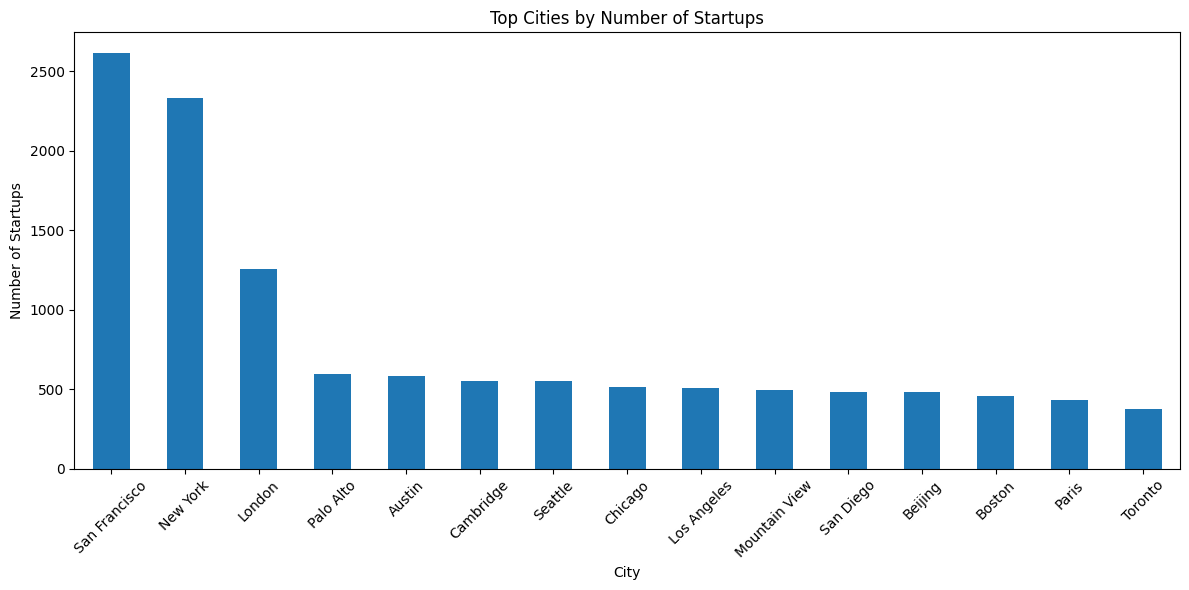

In [19]:
plt.figure(figsize=(12,6))

city_counts.plot(kind="bar")

plt.title("Top Cities by Number of Startups")
plt.xlabel("City")
plt.ylabel("Number of Startups")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Key Insight: Cities with the Most Startups

This analysis identifies the cities with the largest startup populations.

### Findings

- San Francisco has the highest number of startups in the dataset.
- New York ranks second and remains one of the world's largest startup hubs.
- London is the leading startup city outside the United States.
- Several Silicon Valley cities, including Palo Alto and Mountain View, appear among the top startup locations.
- Other major startup ecosystems include Seattle, Los Angeles, Boston, Beijing, Paris, and Toronto.

### Interpretation

Startup activity is highly concentrated in a small number of innovation hubs.

The dominance of San Francisco and nearby Silicon Valley cities highlights the importance of:
- Venture capital availability
- Technology talent
- Research institutions
- Entrepreneurial networks

The presence of cities such as London, Beijing, Paris, and Toronto demonstrates the global nature of startup ecosystems.

### Conclusion

While startups exist worldwide, a relatively small number of cities account for a significant share of startup activity, with San Francisco emerging as the leading startup hub in the dataset.

## Business Question

Which countries attract the largest amount of startup funding?

### Why This Matters

Funding concentration helps identify the strongest startup ecosystems and the regions that attract the most investor capital.

In [20]:
country_funding = (
    df.groupby("country_code")["funding_total_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

country_funding

country_code
USA    4.642448e+11
CHN    3.557720e+10
GBR    2.349814e+10
IND    1.501171e+10
CAN    1.391417e+10
RUS    9.429262e+09
DEU    8.243664e+09
ISR    6.267080e+09
FRA    5.195064e+09
NLD    4.044213e+09
ESP    3.669193e+09
CHE    3.023008e+09
JPN    2.896595e+09
SWE    2.885797e+09
AUS    2.598953e+09
Name: funding_total_usd, dtype: float64

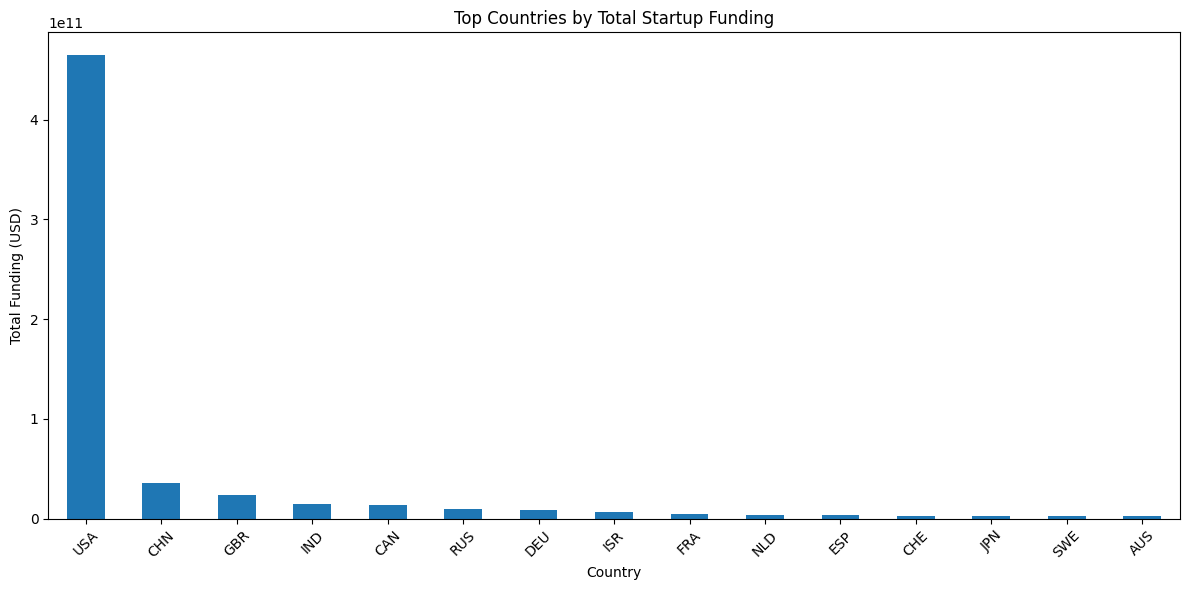

In [21]:
plt.figure(figsize=(12,6))

country_funding.plot(kind="bar")

plt.title("Top Countries by Total Startup Funding")
plt.xlabel("Country")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insight: Countries Attracting the Most Startup Funding

This analysis examines the geographic distribution of startup funding across countries.

### Findings

- The United States attracts by far the largest amount of startup funding.
- China ranks second but receives substantially less funding than the United States.
- The United Kingdom, India, and Canada are among the next most heavily funded startup ecosystems.
- Several European countries, including Germany, France, Spain, Sweden, and Switzerland, appear among the top funding destinations.

### Interpretation

The concentration of funding in the United States reflects the strength of its startup ecosystem, venture capital market, and technology hubs.

China's strong position highlights its growing influence in global innovation and entrepreneurship, while countries such as the United Kingdom, Canada, and India continue to attract significant investment.

### Conclusion

Startup funding is highly concentrated geographically, with the United States serving as the dominant destination for venture capital investment worldwide.

## Business Question

Which cities attract the largest amount of startup funding?

### Why This Matters

Funding concentration at the city level helps identify the world's most important startup and investment hubs.

In [22]:
city_funding = (
    df.groupby("city")["funding_total_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

city_funding

city
New York         6.114184e+10
San Francisco    3.837544e+10
Beijing          1.325378e+10
Palo Alto        1.216894e+10
Cambridge        1.108069e+10
San Diego        1.069502e+10
London           1.041396e+10
Mountain View    9.330810e+09
Moscow           9.279934e+09
San Jose         9.202460e+09
Sunnyvale        8.214516e+09
Redwood City     8.060957e+09
Boston           7.797926e+09
Austin           7.517110e+09
Atlanta          7.498718e+09
Name: funding_total_usd, dtype: float64

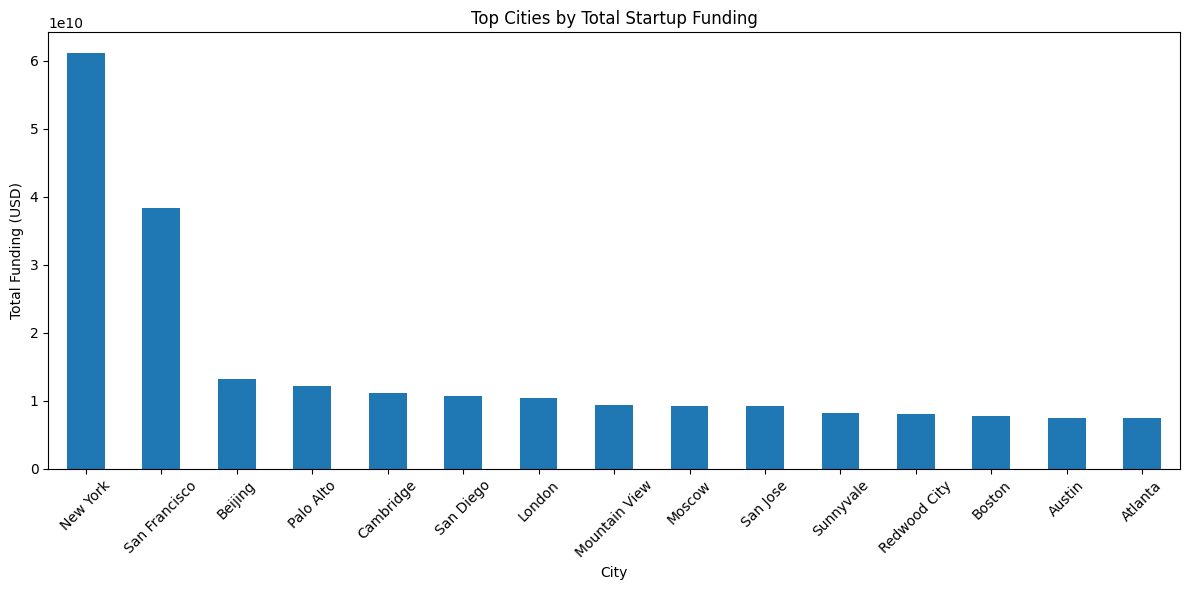

In [23]:
plt.figure(figsize=(12,6))

city_funding.plot(kind="bar")

plt.title("Top Cities by Total Startup Funding")
plt.xlabel("City")
plt.ylabel("Total Funding (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Key Insight: Cities Attracting the Most Startup Funding

This analysis examines which cities receive the largest amount of startup funding.

### Findings

- New York attracts the highest total startup funding in the dataset.
- San Francisco ranks second and remains one of the world's most important startup investment hubs.
- Beijing is the highest-ranked city outside the United States.
- Several Silicon Valley cities, including Palo Alto, Mountain View, Sunnyvale, and Redwood City, appear among the top-funded locations.
- London is the leading European city by total startup funding.

### Interpretation

While San Francisco hosts the largest number of startups, New York attracts the highest total funding.

This suggests that startup ecosystem size and funding concentration are not always the same. Some cities may have fewer startups but attract larger investments per company.

The strong presence of Silicon Valley cities highlights the continued importance of technology clusters in attracting venture capital.

### Conclusion

Startup funding is concentrated in a small number of global innovation hubs, with New York, San Francisco, Beijing, and London serving as major centers for venture capital investment.

## Business Question

Which countries produce the largest number of acquired startups?

### Why This Matters

Startup acquisitions are often considered successful exits and can indicate the maturity and strength of startup ecosystems.

In [24]:
acquired_df = df[df["status"] == "acquired"]

country_acquisitions = (
    acquired_df["country_code"]
    .value_counts()
    .head(15)
)

country_acquisitions

country_code
USA    2785
GBR     141
CAN     103
DEU      73
ISR      60
FRA      47
CHN      25
ESP      24
IND      17
IRL      17
NLD      14
DNK      13
SWE      12
AUS      12
ITA      12
Name: count, dtype: int64

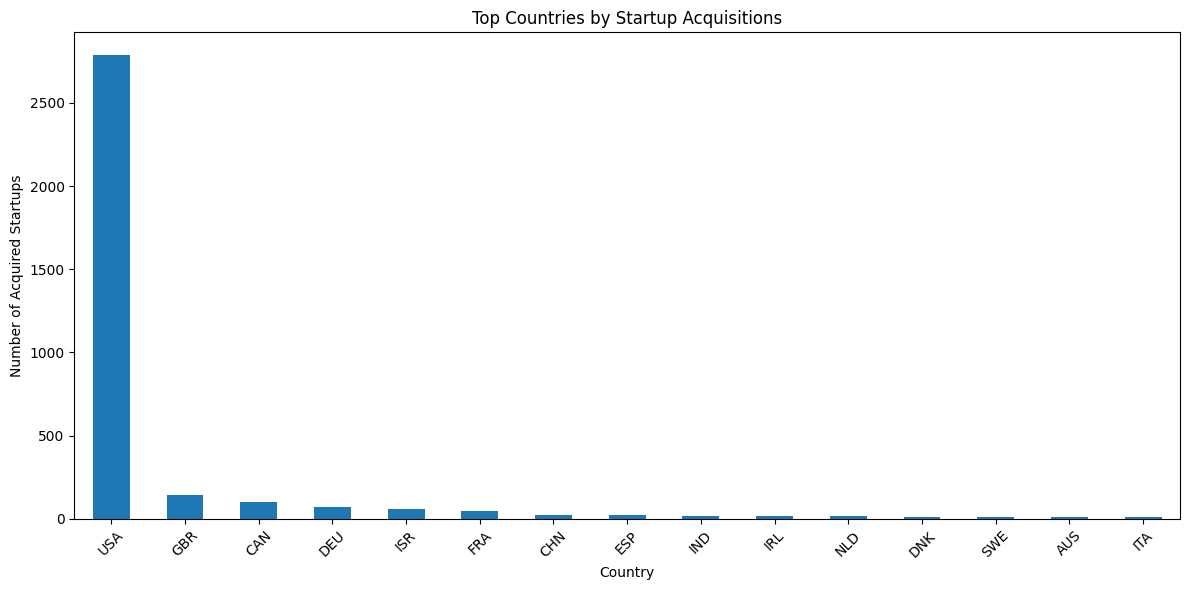

In [25]:
plt.figure(figsize=(12,6))

country_acquisitions.plot(kind="bar")

plt.title("Top Countries by Startup Acquisitions")
plt.xlabel("Country")
plt.ylabel("Number of Acquired Startups")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Key Insight: Countries Producing the Most Startup Acquisitions

This analysis examines the geographic distribution of startup acquisitions across countries.

### Findings

- The United States overwhelmingly leads all countries in the number of startup acquisitions.
- The United Kingdom ranks second but remains far behind the United States.
- Canada, Germany, and Israel are among the next most successful startup ecosystems in terms of acquisitions.
- Most countries outside the United States contribute a relatively small number of acquisitions.

### Interpretation

The dominance of the United States suggests the presence of a highly mature startup ecosystem with:

- Strong venture capital networks
- Large technology markets
- Active merger and acquisition activity
- Established pathways for startup exits

Countries such as the United Kingdom, Canada, Germany, and Israel also demonstrate strong startup ecosystems capable of producing successful acquisitions.

### Conclusion

Startup acquisitions are heavily concentrated in the United States, highlighting its position as the leading global market for startup exits and entrepreneurial success.